In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy import stats
from scipy.stats import rankdata, norm
import seaborn as sns

In [42]:
# import test_salaries.csv as a pandas dataframe
df = pd.read_csv('salaries_3000.csv')
# separate the first 1500 rows of the dataframe into a new dataframe and the last 1500 rows into another dataframe
df_m = df.iloc[:1500]
df_f = df.iloc[1500:]

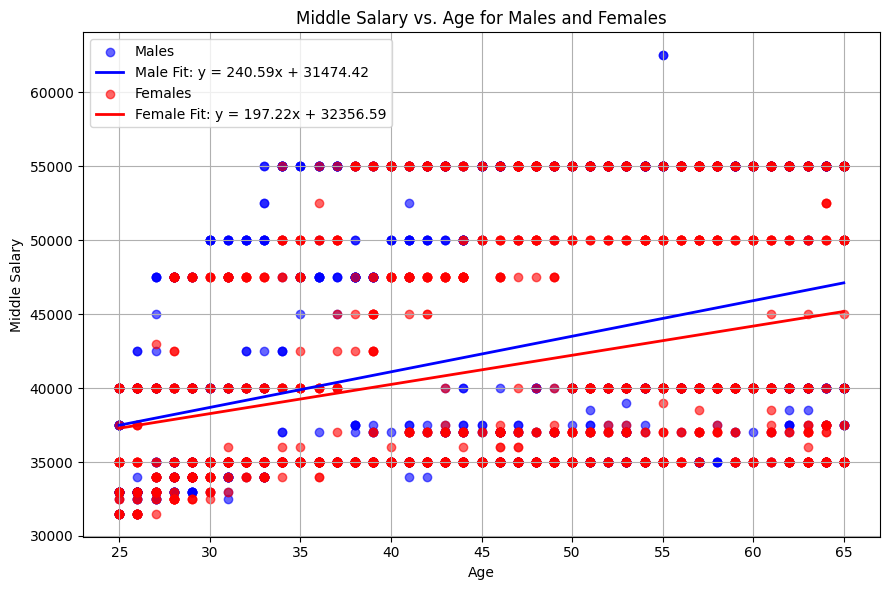

Middle Salary for Males: 42246.33
Middle Salary for Females: 41251.33


In [43]:
# Extract data
ages_m = df_m['age']
salaries_m = df_m['middle_salary']

ages_f = df_f['age']
salaries_f = df_f['middle_salary']

# --- Male regression ---
n_m = len(ages_m)
x_mean_m = sum(ages_m) / n_m
y_mean_m = sum(salaries_m) / n_m
slope_m = sum((ages_m.iloc[i] - x_mean_m) * (salaries_m.iloc[i] - y_mean_m) for i in range(n_m)) / \
          sum((ages_m.iloc[i] - x_mean_m)**2 for i in range(n_m))
intercept_m = y_mean_m - slope_m * x_mean_m

# --- Female regression ---
n_f = len(ages_f)
x_mean_f = sum(ages_f) / n_f
y_mean_f = sum(salaries_f) / n_f
slope_f = sum((ages_f.iloc[i] - x_mean_f) * (salaries_f.iloc[i] - y_mean_f) for i in range(n_f)) / \
          sum((ages_f.iloc[i] - x_mean_f)**2 for i in range(n_f))
intercept_f = y_mean_f - slope_f * x_mean_f

# Regression line values
x_vals = sorted(set(ages_m) | set(ages_f))  # Union of all unique age values
y_vals_m = [slope_m * x + intercept_m for x in x_vals]
y_vals_f = [slope_f * x + intercept_f for x in x_vals]

# --- Plotting ---
plt.figure(figsize=(9, 6))
plt.scatter(ages_m, salaries_m, color='blue', alpha=0.6, label='Males')
plt.plot(x_vals, y_vals_m, color='blue', linewidth=2, label=f'Male Fit: y = {slope_m:.2f}x + {intercept_m:.2f}')

plt.scatter(ages_f, salaries_f, color='red', alpha=0.6, label='Females')
plt.plot(x_vals, y_vals_f, color='red', linewidth=2, label=f'Female Fit: y = {slope_f:.2f}x + {intercept_f:.2f}')

plt.title('Middle Salary vs. Age for Males and Females')
plt.xlabel('Age')
plt.ylabel('Middle Salary')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# also print the mean salary for M and F
mean_salary_m = salaries_m.mean() 
mean_salary_f = salaries_f.mean()
print(f'Middle Salary for Males: {mean_salary_m:.2f}')
print(f'Middle Salary for Females: {mean_salary_f:.2f}')

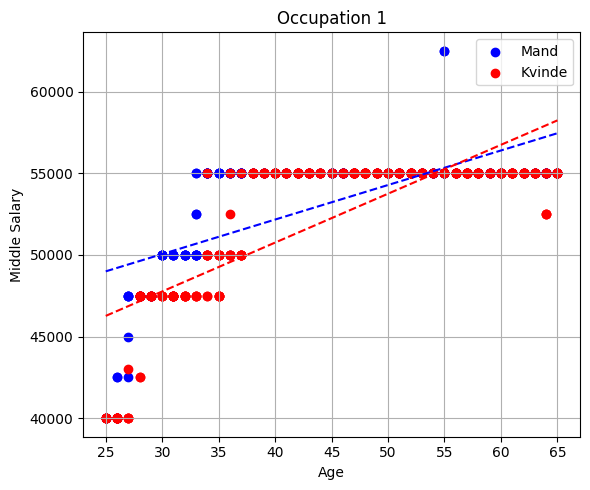

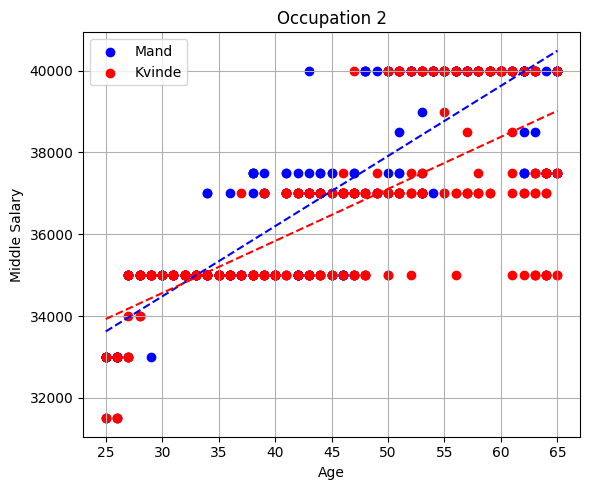

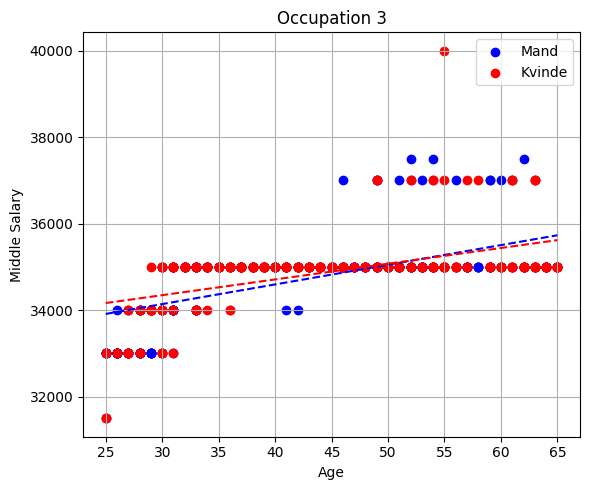

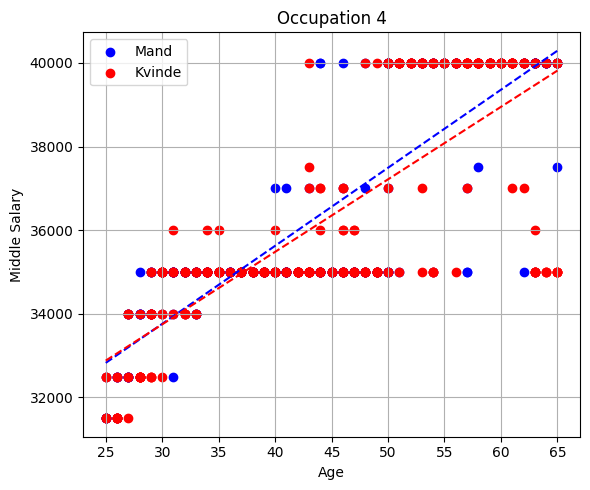

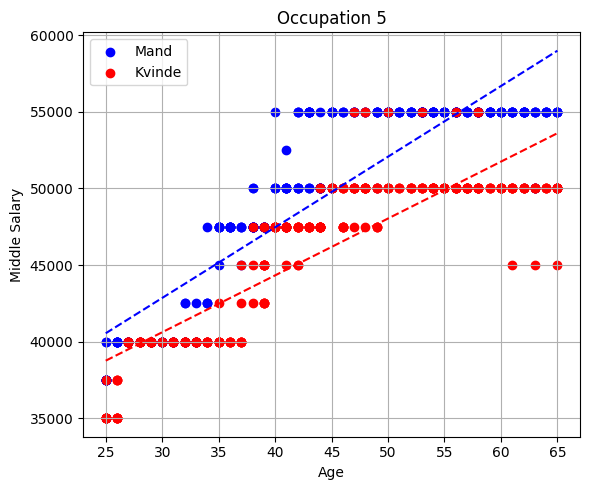

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Indlæs data
df = pd.read_csv("salaries_3000.csv")  # Erstat med korrekt sti

# Farver og labels
colors = {'M': 'blue', 'F': 'red'}
labels = {'M': 'Mand', 'F': 'Kvinde'}

# Gennemløb hver occupation og lav et separat plot
occupations = sorted(df["occupation"].unique())

for occ in occupations:
    subset = df[df["occupation"] == occ]
    plt.figure(figsize=(6, 5))

    for gender in ['M', 'F']:
        data = subset[subset["gender"] == gender]
        plt.scatter(data["age"], data["middle_salary"], color=colors[gender], label=labels[gender])

        # Lineær regression hvis der er nok data
        if len(data) > 1:
            X = data["age"].values.reshape(-1, 1)
            y = data["middle_salary"].values
            model = LinearRegression().fit(X, y)
            x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
            y_pred = model.predict(x_range)
            plt.plot(x_range, y_pred, color=colors[gender], linestyle='--')

    plt.title(f"Occupation {occ}")
    plt.xlabel("Age")
    plt.ylabel("Middle Salary")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [45]:
# Extract the salary data and group labels
x = df_m["middle_salary"].values
y = df_f["middle_salary"].values

n1 = len(x)
n2 = len(y)

# Combine data with group labels
all_values = np.concatenate([x, y])
groups = np.array(['M'] * n1 + ['F'] * n2)

# Rank the combined values
ranks = rankdata(all_values)  # average ranks for ties

# Create a DataFrame to see everything clearly
ranked_df = pd.DataFrame({
    'value': all_values,
    'rank': ranks,
    'group': groups
}).sort_values(by='rank').reset_index(drop=True)

print(ranked_df.head(3000))  # see the top 10 ranks values


      value    rank group
0     31500    13.0     F
1     31500    13.0     F
2     31500    13.0     M
3     31500    13.0     M
4     31500    13.0     F
...     ...     ...   ...
2995  55000  2702.5     F
2996  55000  2702.5     F
2997  55000  2702.5     F
2998  62500  2999.5     M
2999  62500  2999.5     M

[3000 rows x 3 columns]


In [46]:
# Assuming x and y are your arrays for male and female salaries
# Make sure to compare only up to the length of the smaller group
length = min(len(x), len(y))

count_m_greater = 0
count_f_greater = 0
count_m_equal_f = 0
for i in range(length):
    if x[i] > y[i]:
        count_m_greater += 1
    elif x[i] < y[i]:
        count_f_greater += 1
    elif x[i] == y[i]:
        count_m_equal_f += 1

print(f"Number of pairs where male earns more than female: {count_m_greater} out of {length}")
print(f"Number of pairs where female earns more than male: {count_f_greater} out of {length}")
print(f"Number of pairs where male and female earn the same: {count_m_equal_f} out of {length}")


Number of pairs where male earns more than female: 550 out of 1500
Number of pairs where female earns more than male: 366 out of 1500
Number of pairs where male and female earn the same: 584 out of 1500


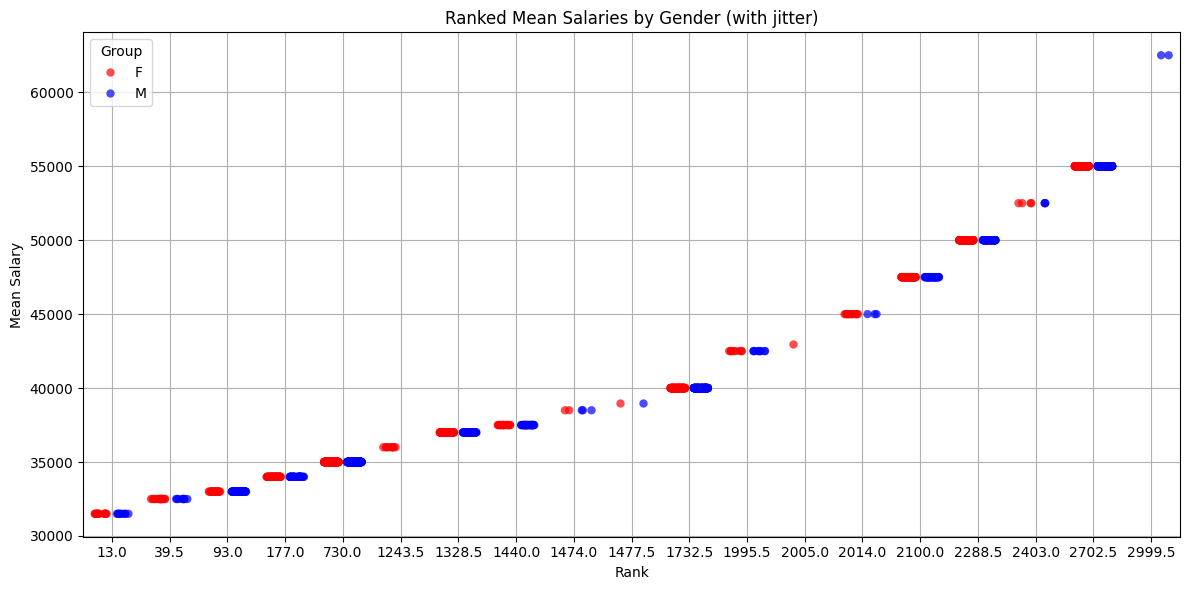

In [47]:
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=ranked_df,
    x='rank',
    y='value',
    hue='group',
    palette={'M': 'blue', 'F': 'red'},
    jitter=0.25,   # Spread dots horizontally
    dodge=True,    # Separate M and F a bit
    alpha=0.7,
    size=6
)

plt.title('Ranked Mean Salaries by Gender (with jitter)')
plt.xlabel('Rank')
plt.ylabel('Mean Salary')
plt.legend(title='Group')
plt.grid(True)
plt.tight_layout()
plt.show()


In [48]:
# Extract values
x = df_m["middle_salary"].values
y = df_f["middle_salary"].values

n1 = len(x)
n2 = len(y)

# Combine and rank
all_values = np.concatenate([x, y])
ranks = rankdata(all_values)

# Group labels
groups = ['M'] * n1 + ['F'] * n2

# Build DataFrame of ranks and groups
df_ranks = pd.DataFrame({
    'Rank': ranks,
    'Group': groups
})

# Group by unique rank and count each gender
summary_table = df_ranks.groupby(['Rank', 'Group']).size().unstack(fill_value=0).reset_index()

# Optional: Rename for clarity
summary_table.columns.name = None
summary_table = summary_table.rename(columns={'M': '# Male', 'F': '# Female'})

print(summary_table)

# Compute rank sums
R1 = df_ranks.loc[df_ranks['Group'] == 'M', 'Rank'].sum()
R2 = df_ranks.loc[df_ranks['Group'] == 'F', 'Rank'].sum()

print(f"R1 (Male rank sum): {R1:.1f}")
print(f"R2 (Female rank sum): {R2:.1f}")


      Rank  # Female  # Male
0     13.0        16       9
1     39.5        19       9
2     93.0        26      53
3    177.0        51      38
4    730.0       512     505
5   1243.5        10       0
6   1328.5       101      59
7   1440.0        21      42
8   1474.0         2       3
9   1477.5         1       1
10  1732.5       248     260
11  1995.5         9       9
12  2005.0         1       0
13  2014.0        14       3
14  2100.0        99      56
15  2288.5       155      67
16  2403.0         4       3
17  2702.5       211     381
18  2999.5         0       2
R1 (Male rank sum): 2313780.0
R2 (Female rank sum): 2187720.0


In [49]:
# Assign ranks back to original groups
ranks_x = ranks[:n1]
ranks_y = ranks[n1:]

# Sum ranks
R1 = np.sum(ranks_x)
R2 = np.sum(ranks_y)

# Compute U values
U1 = n1 * n2 + n1 * (n1 + 1) / 2 - R1
U2 = n1 * n2 + n2 * (n2 + 1) / 2 - R2

U = min(U1, U2)

# Compute mean and std for normal approximation
mu_U = n1 * n2 / 2
sigma_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)

# Compute Z-score
Z = (U - mu_U) / sigma_U

# Compute p-value
p_value = 2 * stats.norm.sf(abs(Z))  # Two-tailed test

print(f"U = {U:.2f}")
print(f"Z = {Z:.2f}")
print(f"abs(Z) = {abs(Z):.2f}")
print(f"From table, p is approximately {p_value} (two-tailed)")

if p_value < 0.05:
    print("p<0.05 : Ignore the next steps. We are not interested in the power.")
else:
    count = 0
    for xi in x:
        for yj in y:
            if xi > yj:
                count += 1

    A = count / (n1 * n2)
    print(f"Count of pairs (X > Y): {count}")
    print(f"Estimated A = P(X > Y) = {A:.4f}")

    
    # A is given from the previous calculation
    delta = abs(A - 0.5)

    alpha = 0.05
    z_alpha = norm.ppf(1 - alpha/2)  # 1.96 for two-tailed 0.05

    n1 = len(x)
    n2 = len(y)
    n = min(n1, n2)  # assume balanced sample size for approximation

    z_beta = np.sqrt(12) * delta * np.sqrt(n) - z_alpha
    power = norm.cdf(z_beta)

    print(f"Estimated power of Mann-Whitney U test: {power}")


U = 1061970.00
Z = -2.66
abs(Z) = 2.66
From table, p is approximately 0.007880780117500189 (two-tailed)
p<0.05 : Ignore the next steps. We are not interested in the power.


### Differences in pay gap based on ground truth data

In [50]:
male_salaries_occ1 = df.loc[(df["occupation"] == 1) & (df["gender"] == "M"), "middle_salary"]
male_salaries_occ2 = df.loc[(df["occupation"] == 2) & (df["gender"] == "M"), "middle_salary"]
male_salaries_occ3 = df.loc[(df["occupation"] == 3) & (df["gender"] == "M"), "middle_salary"]
male_salaries_occ4 = df.loc[(df["occupation"] == 4) & (df["gender"] == "M"), "middle_salary"]
male_salaries_occ5 = df.loc[(df["occupation"] == 5) & (df["gender"] == "M"), "middle_salary"]

female_salaries_occ1 = df.loc[(df["occupation"] == 1) & (df["gender"] == "F"), "middle_salary"]
female_salaries_occ2 = df.loc[(df["occupation"] == 2) & (df["gender"] == "F"), "middle_salary"]
female_salaries_occ3 = df.loc[(df["occupation"] == 3) & (df["gender"] == "F"), "middle_salary"]
female_salaries_occ4 = df.loc[(df["occupation"] == 4) & (df["gender"] == "F"), "middle_salary"]
female_salaries_occ5 = df.loc[(df["occupation"] == 5) & (df["gender"] == "F"), "middle_salary"]


In [51]:
percent_diff = {}

for occ in sorted(df["occupation"].unique()):
    male_mean = df.loc[(df["occupation"] == occ) & (df["gender"] == "M"), "middle_salary"].mean()
    female_mean = df.loc[(df["occupation"] == occ) & (df["gender"] == "F"), "middle_salary"].mean()
    # Percent difference: (male - female) / female * 100
    if female_mean != 0:
        pct = (male_mean - female_mean) / male_mean * 100
    else:
        pct = float('nan')
    percent_diff[occ] = pct
    print(f"Occupation {occ}: Male mean = {male_mean:.2f}, Female mean = {female_mean:.2f}, Percent diff = {pct:.2f}%")

Occupation 1: Male mean = 53383.33, Female mean = 52235.00, Percent diff = 2.15%
Occupation 2: Male mean = 37063.33, Female mean = 36600.00, Percent diff = 1.25%
Occupation 3: Male mean = 34793.33, Female mean = 34873.33, Percent diff = -0.23%
Occupation 4: Male mean = 36391.67, Female mean = 36373.33, Percent diff = 0.05%
Occupation 5: Male mean = 49600.00, Female mean = 46175.00, Percent diff = 6.91%


In [52]:
# True procent wise difference between males and females by occupation in 2023
# These numbers are across all ages, not just from 25 to 60

occ1_true = 6.6
occ2_true = 5.3
occ3_true = 5.6
# occ4_true = data falls under the limit of uncertainty
occ5_true = 14.1

In [53]:
for i in percent_diff.values():
    print(i)

occ1_calc = 2.1983982642544957
occ2_calc = 1.2659380692167643
occ3_calc = -0.22940164404511562
occ4_calc = 0.05040322580643827
occ5_calc = 7.4174336762317274

2.1511083359350653
1.2501124201816773
-0.22992910519256562
0.05037783375313529
6.90524193548387


In [54]:
diff_in_occ1 = abs(occ1_true - occ1_calc)
diff_in_occ2 = abs(occ2_true - occ2_calc)
diff_in_occ3 = abs(occ3_true - occ3_calc)
diff_in_occ5 = abs(occ5_true - occ5_calc)

print(f'Percent wise difference = {diff_in_occ1:.2f}%')
print(f'Percent wise difference = {diff_in_occ2:.2f}%')
print(f'Percent wise difference = {diff_in_occ3:.2f}%')
print(f'Percent wise difference = {diff_in_occ5:.2f}%')

Percent wise difference = 4.40%
Percent wise difference = 4.03%
Percent wise difference = 5.83%
Percent wise difference = 6.68%


##### p-test, Wilcoxon test

$ A_{ao} = g_{ao}^{model} - g_{ao}^{real} $

Where g is defined as:

$ g = \frac{\mu_{male} - \mu_{female}}{\mu_{male}} $

In [55]:
# Firstly, match the age bands:

# Define age bins and labels
bins = [0, 29, 39, 49, 59, np.inf]
labels = ['20-29', '30-39', '40-49', '50-59', '60+']

# Assign each row to an age band
df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Check the distribution
print(df['age_band'].value_counts().sort_index())

# Now you can group by 'age_band' for further analysis
# Example: mean salary by age band
mean_salary_by_band = df.groupby('age_band')['middle_salary'].mean()
print(mean_salary_by_band)

age_band
20-29    358
30-39    741
40-49    737
50-59    740
60+      424
Name: count, dtype: int64
age_band
20-29    36527.932961
30-39    39509.446694
40-49    42611.261872
50-59    44364.864865
60+      44005.896226
Name: middle_salary, dtype: float64


C:\Users\chris\AppData\Local\Temp\ipykernel_27152\102411177.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_salary_by_band = df.groupby('age_band')['middle_salary'].mean()


In [56]:
# Prepare a DataFrame to store results
results = []

# Loop through each occupation and age band
for occ in sorted(df["occupation"].unique()):
    for age_band in df["age_band"].cat.categories:
        # Filter for current occupation and age band
        group = df[(df["occupation"] == occ) & (df["age_band"] == age_band)]
        male_mean = group.loc[group["gender"] == "M", "middle_salary"].mean()
        female_mean = group.loc[group["gender"] == "F", "middle_salary"].mean()
        # Percent difference: (male - female) / male * 100
        if pd.notnull(male_mean) and pd.notnull(female_mean) and male_mean != 0:
            pct_diff = (male_mean - female_mean) / male_mean * 100
        else:
            pct_diff = float('nan')
        results.append({
            "occupation": occ,
            "age_band": age_band,
            "male_mean": male_mean,
            "female_mean": female_mean,
            "percent_diff": pct_diff
        })

# Convert to DataFrame for easy viewing
gap_df = pd.DataFrame(results)
print(gap_df)

# Optionally, pivot for a table view
pivot = gap_df.pivot(index="occupation", columns="age_band", values="percent_diff")
print(pivot)

    occupation age_band     male_mean   female_mean  percent_diff
0            1    20-29  44274.193548  42897.435897      3.109617
1            1    30-39  52673.611111  49927.536232      5.213379
2            1    40-49  55000.000000  55000.000000      0.000000
3            1    50-59  55187.500000  55000.000000      0.339751
4            1      60+  55000.000000  54825.581395      0.317125
5            2    20-29  33783.783784  33806.451613     -0.067097
6            2    30-39  35353.333333  35089.552239      0.746128
7            2    40-49  36557.142857  36200.000000      0.976944
8            2    50-59  39544.776119  38568.181818      2.469591
9            2      60+  39392.156863  37568.181818      4.630300
10           3    20-29  33158.536585  33464.285714     -0.922083
11           3    30-39  34815.789474  34720.430108      0.273897
12           3    40-49  35057.142857  35057.971014     -0.002362
13           3    50-59  35215.189873  35253.731343     -0.109446
14        

In [57]:
# True procent wise difference between males and females by occupation in 2023
# These numbers are across all ages, not just from 25 to 60

# occ1_true:
# 20 - 29: 1.6 %
# 30 - 39: 5.8 %
# 40 - 49: 8.4 %
# 50 - 59: 6.2 %
# 60 +: 6.2 %

# occ2_true:
# 20 - 29: 2.8 %
# 30 - 39: 4.1 %
# 40 - 49: 5.8 %
# 50 - 59: 7.2 %
# 60 +: 9.2 %

# occ3_true:
# 20 - 29: 4.4 %
# 30 - 39: 4.5 %
# 40 - 49: 5.9 %
# 50 - 59: 6.4 %
# 60 +: 5.1 %

# occ4_true: CAN NOT SEE, DATA NOT MADE PUBLIC
# 20 - 29: NaN
# 30 - 39: NaN
# 40 - 49: NaN
# 50 - 59: NaN
# 60 +: NaN

# occ5_true: Sidenote: We use sales and marketing managers
# 20 - 29: 16.3 %
# 30 - 39: 14.5 %
# 40 - 49: 10.2 %
# 50 - 59: 13.2 %
# 60 +: 9.7 %

In [58]:
calc_values = []
true_values = []

true_gap_dict = {
    (1, '20-29'): 1.6,
    (1, '30-39'): 5.8,
    (1, '40-49'): 8.4,
    (1, '50-59'): 6.2,
    (1, '60+'): 6.2,

    (2, '20-29'): 2.8,
    (2, '30-39'): 4.1,
    (2, '40-49'): 5.8,
    (2, '50-59'): 7.2,
    (2, '60+'): 9.2,

    (3, '20-29'): 4.4,
    (3, '30-39'): 4.5,
    (3, '40-49'): 5.9,
    (3, '50-59'): 6.4,
    (3, '60+'): 5.1,

    # occ4_true: all NaN, so not included

    (5, '20-29'): 16.3,
    (5, '30-39'): 14.5,
    (5, '40-49'): 10.2,
    (5, '50-59'): 13.2,
    (5, '60+'): 9.7,
}

for idx, row in gap_df.iterrows():
    key = (row['occupation'], row['age_band'])
    if key in true_gap_dict:
        calc = row['percent_diff']
        true = true_gap_dict[key]
        if not (np.isnan(calc) or np.isnan(true)):
            calc_values.append(calc)
            true_values.append(true)

# Now run the one-sided Wilcoxon signed-rank test
stat, p = stats.wilcoxon(calc_values, true_values, alternative='greater')
print(f"Wilcoxon signed-rank test (one-sided, calc > true): statistic={stat}, p-value={p}")

Wilcoxon signed-rank test (one-sided, calc > true): statistic=3.0, p-value=0.9999971389770508


At a $\alpha = 0.05, 0.99999971 > 0.05$ we fail to rejct the null hypothesis, being that the median difference between the gender pay gaps are equal to zero. Our alternative is set to greater, such that 


it can seen that our calculated values are systematically lower than the other group. There is therefore statistical evidence that DeepSeek significantly reduces the true gender pay gap. This shows that the model attenuates (opposite of amplify) the gender pay inequality. In addition, this indicates that the DeepSeek-V3 model has been trained on parameters to make the model less likely to amplify inequalites. However, this is still shows that the model exhibits bias, as the values it gives still morph and cloud the reality of the true gender pay gap. 

It should be noted, that our prompts only include ages ranging from 25 up to 65, whereas Denmarks Statitics show ages varying from 18 to 65+. This should however not disprove our test (why?).  

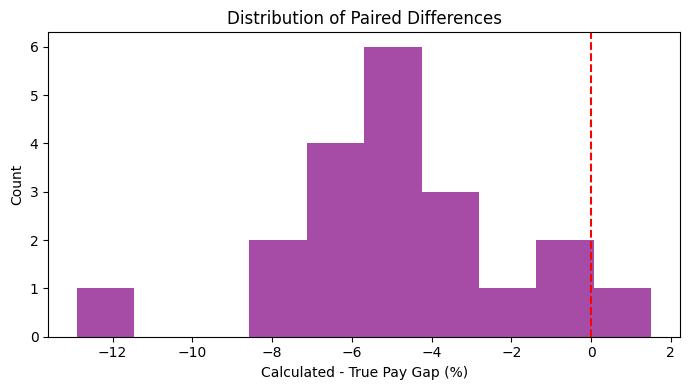

In [60]:
# Histogram of differences
diffs = np.array(calc_values) - np.array(true_values)
plt.figure(figsize=(7, 4))
plt.hist(diffs, bins=10, color='purple', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Calculated - True Pay Gap (%)')
plt.ylabel('Count')
plt.title('Distribution of Paired Differences')
plt.tight_layout()
plt.show()